In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/chandanverma07/DataSets/master/weight-height.csv"
dataset = pd.read_csv(url)

In [3]:
dataset.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
X = dataset[['Height', 'Weight']].values
Y = dataset['Gender'].map({'Male':0, 'Female':1}).values

In [5]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [6]:
X = scalar.fit_transform(X)

In [7]:
from sklearn.svm import LinearSVC
model = LinearSVC()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)

In [9]:
model.fit(X_train, Y_train)

c:\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [10]:
Y_Pred = model.predict(X_test)
Y_Decision = model.decision_function(X_test)

In [11]:
from sklearn.metrics import hinge_loss, accuracy_score
print(hinge_loss(Y_Pred, Y_Decision))
print(accuracy_score(Y_Pred, Y_test))

0.20419194332159168
0.922


In [12]:
import matplotlib.pyplot as plt
import numpy as np

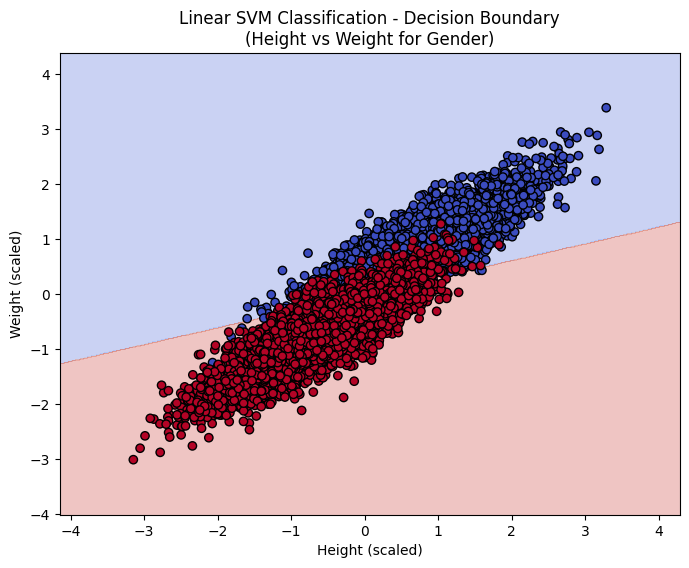

In [13]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 500),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 500))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', edgecolors='k')
plt.xlabel('Height (scaled)')
plt.ylabel('Weight (scaled)')
plt.title('Linear SVM Classification - Decision Boundary\n(Height vs Weight for Gender)')
plt.show()